# **Datalab II Sprint 3 2025 - 2026**
**Plaats:** De Haagse Hogenschool, ADS & AI<br>
**Auteurs:** M. Kilinc, D. Hoogenbosch, J. Wolthuis, S. Slingerland, L. van Hamersveld<br>
**Groep:** B2 <br>
**Coach:** Onur Tezel <br>
**Datum:** 10/03/2026


| Naam  | Studentnummer |
|-------|---------------|
| Lucas | 25076116      |
| Sandro| 25154370      |
| Memhet| 25135007      |
| Julius| 25090216      |
| Dylan | 25118498      |
---

## **Inhoudsopgave**
1. [Imports & Configuratie](#1)
2. [Data inladen](#2)
3. [Data Exploration](#3)

---
<a id='1'></a>
## **1. Imports & Configuratie**

In [12]:
# Imports
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Nieuwe visualisatie bibliotheken
import plotly.express as px
import nbformat
from scipy.stats import pearsonr, f_oneway

---
<a id='2'></a>
## **2. Data inladen**



### **2.1 Gebruik van de Kaggle API** 
We gebruiken de Kaggle API om de data lokaal op te slaan en dit hoeft slechts eenmalig te gebeuren.<br>Download de API-sleutel uit onze GitHub-repository en plaats deze in de map C:\Users\<Jouw_gebruikersnaam>\.kaggle. <br>

Raadpleeg voor verdere instructies de officiële documentatie op https://www.kaggle.com/docs/api.<br>
Verwijder eventueel het # in het script, voer de pip install en de data-import uit en je bent klaar om de data lokaal te gebruiken.


In [8]:
# %pip install kaggle 
import os
from pathlib import Path
import kaggle

# 1) Maak schrijfbare map
download_dir = Path.home() / "Downloads" / "kaggle_data"
download_dir.mkdir(parents=True, exist_ok=True)

# 2) Auth
kaggle.api.authenticate()

# 3) Download naar die map
kaggle.api.dataset_download_files(
    "hugomathien/soccer",
    path=str(download_dir),
    unzip=True
)

print("Klaar! Data staat in:", download_dir)

Dataset URL: https://www.kaggle.com/datasets/hugomathien/soccer
Klaar! Data staat in: /Users/mehmetalikilinc/Downloads/kaggle_data


In [9]:
conn = sqlite3.connect("/Users/mehmetalikilinc/Downloads/kaggle_data/database.sqlite")
df = pd.read_sql("SELECT * FROM Match LIMIT 5;", conn)
display(df)

,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,...,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,...,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,...,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,...,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,...,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67


---
<a id='3'></a>
## **3. Data Exploration**

### **3.1 Aantal gespeelde wedstrijden per seizoen** 

In [11]:
AZ_API_ID = 10229
AZ_FIFA_ID = 1906

query  = f"""

SELECT season, COUNT(*) AS aantal_gespeelde_wedstrijden
FROM Match

WHERE home_team_api_id = {AZ_API_ID}
   OR away_team_api_id = {AZ_API_ID}

GROUP BY season
ORDER BY season;

"""
# Opslaan data uit query in DataFrame
df = pd.read_sql(query, connection)

# DataFrame
display(df)

# Printen samenvatting ondervindingen 
print(f'AZ alkmaar is sinds seizoen 1998/1999 onafgebroken in de Eredivisie een speelde: {df["aantal_gespeelde_wedstrijden"].sum()} wedstrijden')


NameError: name 'connection' is not defined

---
### **3.2 Aantal gespeelde wedstrijden kalender jaar 2010** 

In [ ]:
# In deze query wordt gebruik gemaakt van strftime (string format time) 
# Deze functie converteert datum en tijdobjecten naar leesbare tekenreeksen op basis van specifieke opmaakcodes

query  = f"""

SELECT season, COUNT(*) AS gespeelde_wedstrijden
FROM Match

WHERE (home_team_api_id = {AZ_API_ID} OR 
away_team_api_id = {AZ_API_ID})
AND strftime('%Y', date) = '2010' 

GROUP BY season
ORDER BY season;

"""

# Opslaan data uit query in DataFrame
df = pd.read_sql(query, connection)

# DataFrame
display(df)

# Printen samenvatting ondervindingen 
print(f'In het kalender jaar 2010 speelde AZ: {df["gespeelde_wedstrijden"].sum()} wedstrijden')

,season,gespeelde_wedstrijden
0,2009/2010,16
1,2010/2011,18


In het kalender jaar 2010 speelde AZ: 34 wedstrijden


---
### **3.3 Punten per seizoen & eindklassering** 

In [ ]:
query  = f"""

SELECT season, COUNT(*) AS gespeelde_wedstrijden
FROM Match

WHERE (home_team_api_id = {AZ_API_ID} OR 
away_team_api_id = {AZ_API_ID})
AND strftime('%Y', date) = '2010' 

GROUP BY season
ORDER BY season;

"""

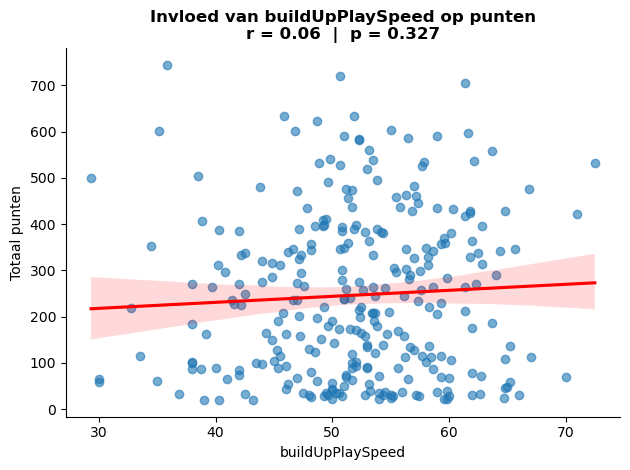

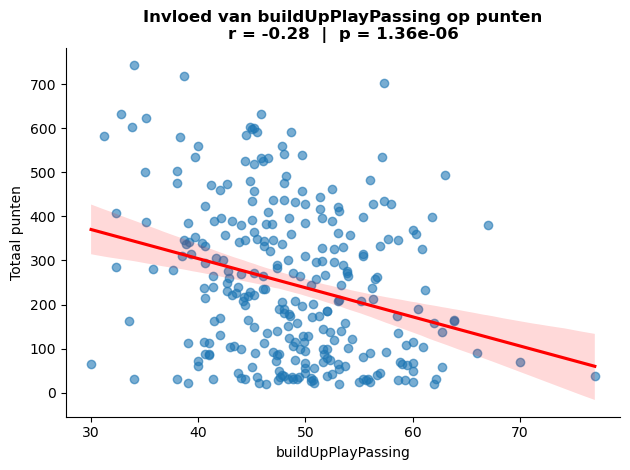

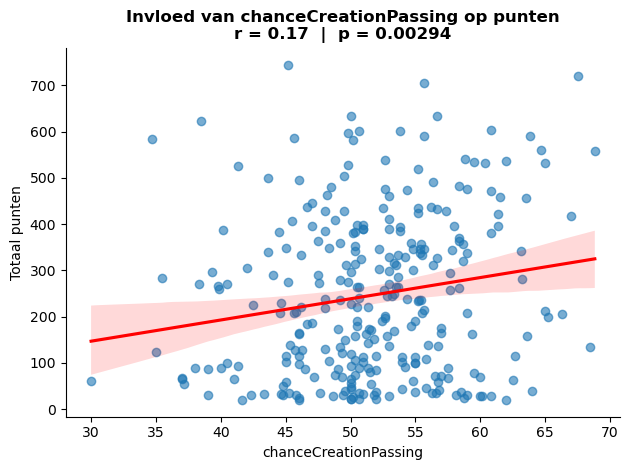

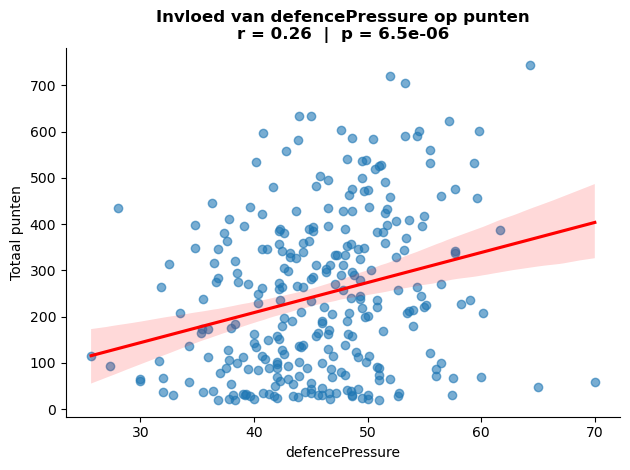

,variabele,r,p,n
1,buildUpPlayPassing,-0.280145,0.000001,288
3,defencePressure,0.262194,0.000007,288
2,chanceCreationPassing,0.174651,0.002940,288
0,buildUpPlaySpeed,0.057984,0.326806,288


/var/folders/pb/mn1mczd545z8szk34y674csm0000gn/T/ipykernel_23324/2804435053.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=col, y='points', order=order, palette='Blues_d')


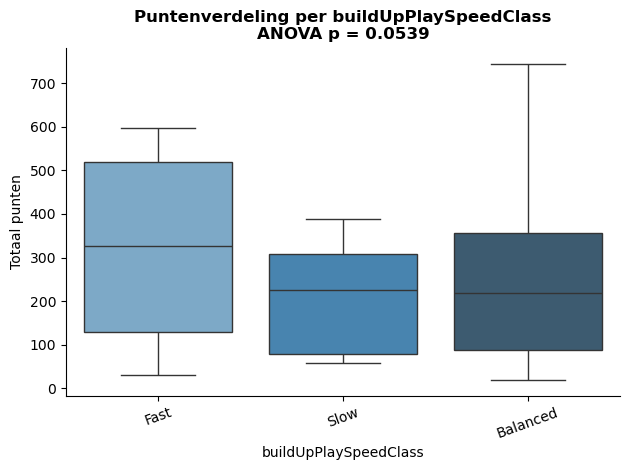

/var/folders/pb/mn1mczd545z8szk34y674csm0000gn/T/ipykernel_23324/2804435053.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=col, y='points', order=order, palette='Blues_d')


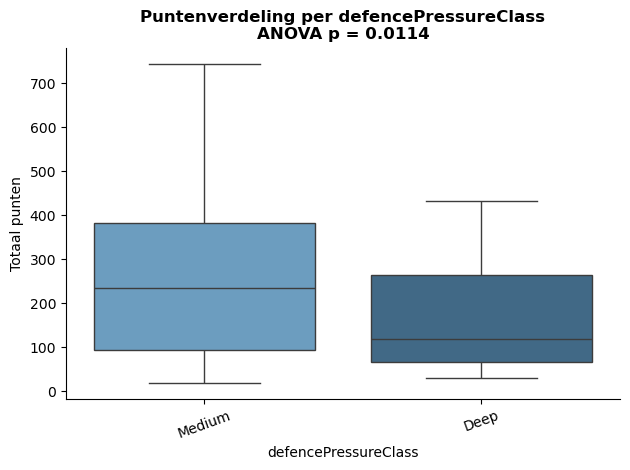

,variabele,anova_F,p,n
1,defencePressureClass,6.484923,0.011407,286
0,buildUpPlaySpeedClass,2.950375,0.053920,288


In [13]:
# --- Opdracht 2b: invloed teameigenschappen op punten ---
from scipy.stats import pearsonr, f_oneway

points_q = """
WITH team_points AS (
    SELECT home_team_api_id AS team_api_id,
           CASE WHEN home_team_goal > away_team_goal THEN 3
                WHEN home_team_goal = away_team_goal THEN 1 ELSE 0 END AS points
    FROM Match
    UNION ALL
    SELECT away_team_api_id AS team_api_id,
           CASE WHEN away_team_goal > home_team_goal THEN 3
                WHEN away_team_goal = home_team_goal THEN 1 ELSE 0 END AS points
    FROM Match
)
SELECT team_api_id, SUM(points) AS points
FROM team_points
GROUP BY team_api_id
"""
points_df = pd.read_sql(points_q, conn)

attrs_num_q = """
SELECT team_api_id,
       AVG(buildUpPlaySpeed)      AS buildUpPlaySpeed,
       AVG(buildUpPlayPassing)    AS buildUpPlayPassing,
       AVG(chanceCreationPassing) AS chanceCreationPassing,
       AVG(defencePressure)       AS defencePressure
FROM Team_Attributes
GROUP BY team_api_id
"""
attrs_num_df = pd.read_sql(attrs_num_q, conn)

attrs_cat_q = """
SELECT ta.team_api_id,
       ta.buildUpPlaySpeedClass,
       ta.defencePressureClass
FROM Team_Attributes ta
JOIN (
    SELECT team_api_id, MAX(date) AS max_date
    FROM Team_Attributes
    GROUP BY team_api_id
) latest
  ON ta.team_api_id = latest.team_api_id
 AND ta.date        = latest.max_date
"""
attrs_cat_df = pd.read_sql(attrs_cat_q, conn).drop_duplicates(subset=['team_api_id'])

data_2b = (points_df
           .merge(attrs_num_df, on='team_api_id', how='inner')
           .merge(attrs_cat_df, on='team_api_id', how='left'))

num_vars = ['buildUpPlaySpeed', 'buildUpPlayPassing', 'chanceCreationPassing', 'defencePressure']
cat_vars = ['buildUpPlaySpeedClass', 'defencePressureClass']


# ── Functies ────────────────────────────────────────────────────────────────

def plot_numeric_vs_points(data: pd.DataFrame, col: str) -> dict:
    """
    Visualiseert de relatie tussen een numerieke teameigenschap en punten
    via een regressieplot en berekent de Pearson-correlatie.

    Parameters
    ----------
    data : pd.DataFrame
        Gecombineerde dataset met teameigenschappen en totaal punten.
    col : str
        Naam van de numerieke kolom om te analyseren.

    Returns
    -------
    dict
        {'variabele', 'r', 'p', 'n'} of leeg dict als te weinig data.
    """
    sub = data[[col, 'points']].dropna()
    if len(sub) < 5 or sub[col].nunique() < 2:
        return {}

    r, p = pearsonr(sub[col], sub['points'])

    sns.regplot(data=sub, x=col, y='points',
                scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
    plt.title(f'Invloed van {col} op punten\nr = {r:.2f}  |  p = {p:.3g}', fontweight='bold')
    plt.ylabel('Totaal punten')
    sns.despine()
    plt.tight_layout()
    plt.show()

    return {'variabele': col, 'r': r, 'p': p, 'n': len(sub)}


def plot_categorical_vs_points(data: pd.DataFrame, col: str) -> dict:
    """
    Visualiseert het verschil in punten per categorie via een boxplot
    en toetst significantie met een eenweg ANOVA.

    Parameters
    ----------
    data : pd.DataFrame
        Gecombineerde dataset met teameigenschappen en totaal punten.
    col : str
        Naam van de categoriale kolom om te analyseren.

    Returns
    -------
    dict
        {'variabele', 'anova_F', 'p', 'n'} of leeg dict als te weinig data.
    """
    sub = data[[col, 'points']].dropna()
    counts = sub[col].value_counts()
    sub = sub[sub[col].isin(counts[counts >= 5].index)]
    if sub[col].nunique() < 2:
        return {}

    groups = [g['points'].values for _, g in sub.groupby(col)]
    F, p = f_oneway(*groups)

    order = sub.groupby(col)['points'].median().sort_values(ascending=False).index
    sns.boxplot(data=sub, x=col, y='points', order=order, palette='Blues_d')
    plt.title(f'Puntenverdeling per {col}\nANOVA p = {p:.3g}', fontweight='bold')
    plt.ylabel('Totaal punten')
    plt.xticks(rotation=20)
    sns.despine()
    plt.tight_layout()
    plt.show()

    return {'variabele': col, 'anova_F': F, 'p': p, 'n': len(sub)}


# ── Uitvoering ───────────────────────────────────────────────────────────────

num_results = [plot_numeric_vs_points(data_2b, col)
               for col in num_vars if col in data_2b.columns]
num_summary = pd.DataFrame([r for r in num_results if r])
if not num_summary.empty:
    num_summary = num_summary.sort_values('r', key=lambda s: s.abs(), ascending=False)
display(num_summary)

cat_results = [plot_categorical_vs_points(data_2b, col)
               for col in cat_vars if col in data_2b.columns]
cat_summary = pd.DataFrame([r for r in cat_results if r])
if not cat_summary.empty:
    cat_summary = cat_summary.sort_values('p')
display(cat_summary)

### Interpretatie – Opdracht 2b

**Numerieke variabelen (Pearson-correlatie, n = 288)**

| Variabele | r | p |
|---|---|---|
| buildUpPlayPassing | −0.28 | < 0.001 |
| defencePressure | +0.26 | < 0.001 |
| chanceCreationPassing | +0.17 | 0.003 |
| buildUpPlaySpeed | +0.06 | 0.327 |

- **buildUpPlayPassing** heeft de sterkste (negatieve) correlatie: teams die de bal lager/korter rondspelen scoren gemiddeld *meer* punten (r = −0.28, p < 0.001). Dit is statistisch significant.
- **defencePressure** laat een positief verband zien: hogere pressing hangt samen met meer punten (r = +0.26, p < 0.001), ook significant.
- **chanceCreationPassing** heeft een zwak positief verband (r = +0.17, p = 0.003), nog net significant.
- **buildUpPlaySpeed** toont geen significant verband (r = +0.06, p = 0.327); speelsnelheid alleen voorspelt punten niet.

**Categoriale variabelen (eenweg ANOVA)**

| Variabele | F | p |
|---|---|---|
| defencePressureClass | 6.48 | 0.011 |
| buildUpPlaySpeedClass | 2.95 | 0.054 |

- **defencePressureClass** laat een significant verschil in punten zien tussen pressingsklassen (F = 6.48, p = 0.011): teams in de hogere pressingsklasse behalen aantoonbaar meer punten.
- **buildUpPlaySpeedClass** zit net boven de drempel van p = 0.05 (p = 0.054) en is daarmee niet significant; het verschil in punten tussen snelheidsklassen kan op toeval berusten.